In [3]:
#Importations
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.4/101.7 MB 4.8 MB/s eta 0:00:21
   - -------------------------------------- 2.9/101.7 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 3.4/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 3.9/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 4.7/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 5.2/101.7 MB 3.2 MB/s eta 0:00:30
   -- ------------------------------------- 5.2/101.7 MB 3.2 MB/s eta 0:00:30
   -- ------------------------------------- 6.0/101.7 MB 3.0 MB/s eta 0:00:33
   -- ------------------------------------- 6.8/101.7 MB 3.0 MB/s eta 0:00:32
   --- ------------------------------------ 7.9/101.7 MB 3.3 MB/s eta 0:00:29


In [4]:
df_imputed = pd.read_csv("../../data/weatherAUS_ForModel.csv")

X = df_imputed.drop(columns=["RainTomorrow", "Date", "SeasonName"], errors="ignore")
y = df_imputed["RainTomorrow"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Shape X: (140091, 22)
Shape y: (140091,)
Train size: (112072, 22)
Test size: (28019, 22)


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:47:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC XGBoost (sans SMOTE): 0.890984574588982
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     21757
           1       0.77      0.54      0.64      6262

    accuracy                           0.86     28019
   macro avg       0.82      0.75      0.77     28019
weighted avg       0.85      0.86      0.85     28019



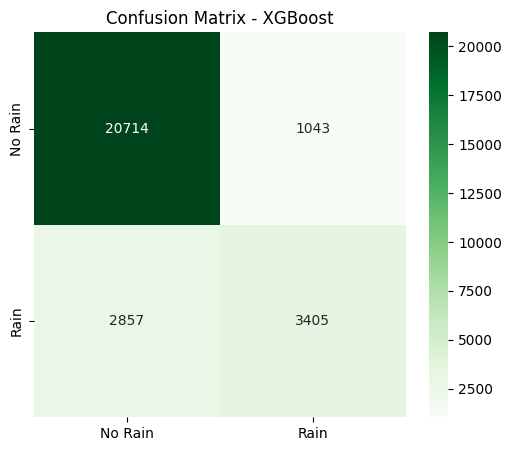

In [5]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
print("ROC-AUC XGBoost (sans SMOTE):", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [6]:
results_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_xgb,
    "Predicted_Probability": y_prob_xgb
})
results_xgb.head(10)

,Actual,Predicted_Class,Predicted_Probability
0,0,0,0.187989
1,1,0,0.038445
2,0,0,0.137584
3,0,0,0.329246
4,0,0,0.066970
5,0,0,0.018156
6,0,0,0.031130
7,0,0,0.108699
8,0,0,0.156872
9,0,0,0.069635


XGBoost With SMOTE

In [7]:
print("Avant SMOTE :")
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Après SMOTE :")
print(y_train_smote.value_counts())

Avant SMOTE :
RainTomorrow
0    87025
1    25047
Name: count, dtype: int64
Après SMOTE :
RainTomorrow
0    87025
1    87025
Name: count, dtype: int64


In [8]:
xgb_model_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_model_smote.predict(X_test)
y_prob_xgb_smote = xgb_model_smote.predict_proba(X_test)[:,1]

c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:48:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC XGBoost + SMOTE: 0.8857910750413305
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     21757
           1       0.73      0.57      0.64      6262

    accuracy                           0.86     28019
   macro avg       0.81      0.75      0.78     28019
weighted avg       0.85      0.86      0.85     28019



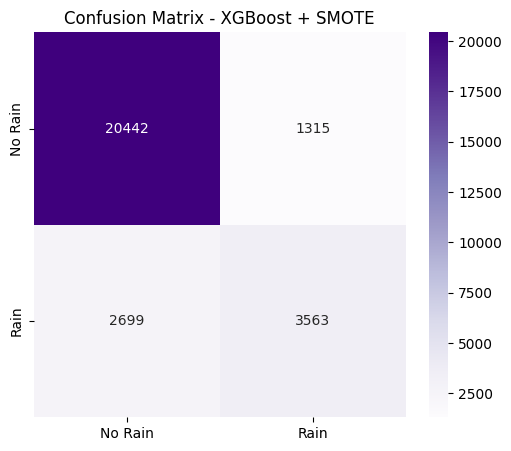

In [9]:
print("ROC-AUC XGBoost + SMOTE:", roc_auc_score(y_test, y_prob_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote))
results_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_xgb_smote,
    "Predicted_Probability": y_prob_xgb_smote
})
results_xgb.head(10)
cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb_smote,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)
plt.title("Confusion Matrix - XGBoost + SMOTE")
plt.show()

XGBoost avec pondération des classes


================ XGBoost (scale_pos_weight) ================

Ratio: 3.4744680001596997


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:50:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC XGBoost + weight: 0.8919782011368067
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     21757
           1       0.54      0.81      0.65      6262

    accuracy                           0.81     28019
   macro avg       0.74      0.81      0.76     28019
weighted avg       0.85      0.81      0.82     28019



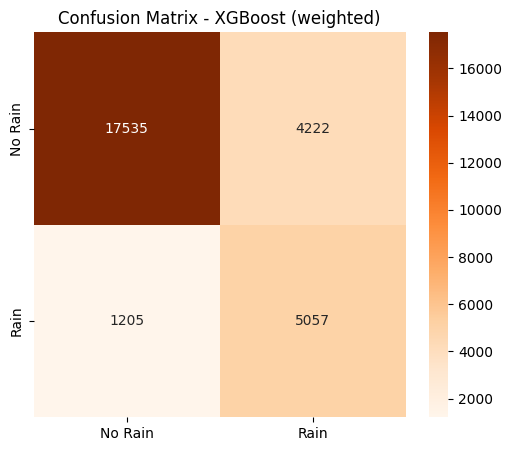

In [10]:
print("\n================ XGBoost (scale_pos_weight) ================\n")


neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

print("Ratio:", ratio)


xgb_model_weight = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio,   
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model_weight.fit(X_train, y_train)


y_prob_xgb_weight = xgb_model_weight.predict_proba(X_test)[:,1]

threshold = 0.45
y_pred_xgb_weight = (y_prob_xgb_weight >= threshold).astype(int)


print("ROC-AUC XGBoost + weight:", roc_auc_score(y_test, y_prob_xgb_weight))
print(classification_report(y_test, y_pred_xgb_weight))

# 🔹 Matrice de confusion
cm_xgb_weight = confusion_matrix(y_test, y_pred_xgb_weight)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb_weight,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - XGBoost (weighted)")
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

print("\n================ TABLEAU COMPARATIF XGBOOST ================\n")

threshold = 0.45
results_xgb = []


# NORMAL

y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

results_xgb.append({
    "Model": "XGB Normal",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "F1": f1_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
})


# SMOTE

y_pred_xgb_smote = (y_prob_xgb_smote >= threshold).astype(int)

results_xgb.append({
    "Model": "XGB + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_smote),
    "F1": f1_score(y_test, y_pred_xgb_smote),
    "Recall": recall_score(y_test, y_pred_xgb_smote),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_smote)
})


# WEIGHT

y_pred_xgb_weight = (y_prob_xgb_weight >= threshold).astype(int)

results_xgb.append({
    "Model": "XGB + weight",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_weight),
    "F1": f1_score(y_test, y_pred_xgb_weight),
    "Recall": recall_score(y_test, y_pred_xgb_weight),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_weight)
})


df_xgb = pd.DataFrame(results_xgb)
print(df_xgb)


================ TABLEAU COMPARATIF XGBOOST ================

          Model  Accuracy        F1    Recall   ROC-AUC
0    XGB Normal  0.860880  0.652399  0.584158  0.890985
1   XGB + SMOTE  0.854099  0.651789  0.610987  0.885791
2  XGB + weight  0.806310  0.650795  0.807569  0.891978
